# LSTM을 이용한 삼성전자 주가 예측

### 실습 목표
- 시계열 데이터를 딥러닝으로 처리하는 방법을 이해합니다
- **슬라이딩 윈도우(Sliding Window)** 방식으로 시퀀스 데이터를 만들어봅니다
- `nn.Module` 클래스를 직접 구현하여 **LSTM 모델**을 만들어봅니다
- 실제 주가 데이터로 다음 날 종가를 예측해봅니다

### Contents
1. 환경 설정
2. 데이터 불러오기
3. 데이터 전처리
4. 시퀀스 데이터 생성
5. Train / Test 분할 및 DataLoader 구성
6. LSTM 모델 정의
7. 모델 학습
8. 예측 및 시각화
9. 연습 문제


## 0. 환경 설정

DL 관련 라이브러리를 설치하고 불러옵니다.

- `FinanceDataReader` : 한국·미국 주식, 암호화폐 등 금융 데이터 수집 라이브러리


In [ ]:
!pip install -q finance-datareader


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.1 MB/s eta 0:00:00


In [ ]:
import FinanceDataReader as fdr
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
print(DEVICE)


cuda


## 1. 데이터 불러오기

`FinanceDataReader`를 사용하여 **삼성전자(005930)** 의 주가 데이터를 불러옵니다.

아래 종목 코드를 바꾸면 다른 종목도 바로 사용할 수 있습니다.

```
"005930" : 삼성전자
"005380" : 현대자동차
"000660" : SK하이닉스
"035720" : 카카오
```

#### 컬럼 설명
- `Open`   : 시가 (장 시작 시 가격)
- `High`   : 고가 (하루 중 가장 높은 가격)
- `Low`    : 저가 (하루 중 가장 낮은 가격)
- `Close`  : 종가 (장 마감 시 가격) ← **예측 목표**
- `Volume` : 거래량


In [ ]:
# ✅ 1. 데이터 불러오기
ticker = "005930"  # 삼성전자
df = fdr.DataReader(ticker, "2020", "2024")
df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()

print(f"기간  : {df.index[0].date()} ~ {df.index[-1].date()}")
print(f"shape : {df.shape}")
df.head()


기간  : 2020-01-02 ~ 2023-12-28
shape : (987, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,55500,56000,55000,55200,12993228
2020-01-03,56000,56600,54900,55500,15422255
2020-01-06,54900,55600,54600,55500,10278951
2020-01-07,55700,56400,55600,55800,10009778
2020-01-08,56200,57400,55900,56800,23501171


/tmp/ipykernel_2207/2495338041.py:8: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2207/2495338041.py:8: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2207/2495338041.py:8: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2207/2495338041.py:8: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2207/2495338041.py:8: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2207/2495338041.py:8: UserWarning: Glyph 49340 (\N{HANGUL SYLLABLE SAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2207/2495338041.py:8: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layou

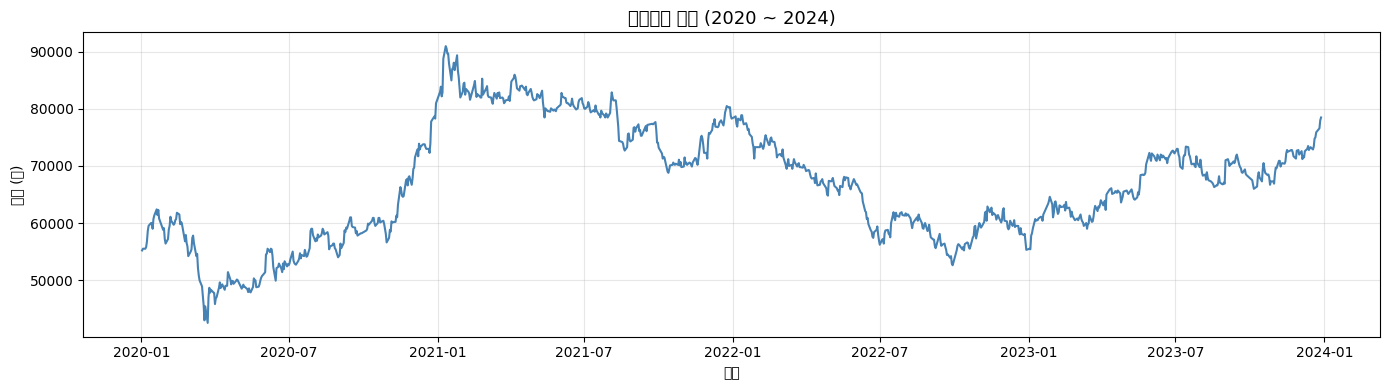

In [ ]:
# ✅ 2. 종가 시각화
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Close"], color="steelblue", linewidth=1.5)
plt.title("Samsung Electronics Close Price (2020 ~ 2024)", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Close Price (KRW)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2. 데이터 전처리

### 왜 정규화가 필요한가요?

피처마다 값의 단위와 범위가 다릅니다.

| 피처 | 대략적인 범위 |
|---|---|
| Close | 50,000 ~ 90,000 (원) |
| Volume | 수백만 ~ 수천만 |

그대로 학습하면 값이 큰 피처가 학습을 지배하게 됩니다.  
`MinMaxScaler`를 사용하면 모든 값을 **0 ~ 1 범위**로 맞춰줄 수 있습니다.


In [ ]:
# ✅ 3. MinMaxScaler로 정규화 (0 ~ 1)
scaler = MinMaxScaler()
df[["Open", "High", "Low", "Close", "Volume"]] = scaler.fit_transform(
    df[["Open", "High", "Low", "Close", "Volume"]]
)

print("정규화 후 데이터 (앞 5행)")
df.head()


정규화 후 데이터 (앞 5행)


,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,0.270440,0.233803,0.269068,0.261856,0.085468
2020-01-03,0.280922,0.245070,0.266949,0.268041,0.114201
2020-01-06,0.257862,0.226291,0.260593,0.268041,0.053361
2020-01-07,0.274633,0.241315,0.281780,0.274227,0.050177
2020-01-08,0.285115,0.260094,0.288136,0.294845,0.209766


In [ ]:
# ✅ 4. 입력(X)과 정답(y) 배열로 분리
#   X : Open, High, Low, Volume  (4가지 피처)
#   y : Close (종가)  ← 예측 목표
x = df[["Open", "High", "Low", "Volume"]].values
y = df["Close"].values

print(f"x shape : {x.shape}  →  (날짜 수, 피처 수)")
print(f"y shape : {y.shape}  →  (날짜 수,)")


x shape : (987, 4)  →  (날짜 수, 피처 수)
y shape : (987,)  →  (날짜 수,)


## 3. 시퀀스 데이터 생성

LSTM은 **순서가 있는 시퀀스 데이터**를 입력으로 받습니다.

**슬라이딩 윈도우(Sliding Window)** 방식으로,  
과거 `sequence_length`일 동안의 데이터를 보고 다음 날의 종가를 예측하도록  
데이터를 재구성합니다.

```
sequence_length = 5 라고 가정하면

[Day 1 ~ Day 5]  →  예측: Day 6 종가
[Day 2 ~ Day 6]  →  예측: Day 7 종가
[Day 3 ~ Day 7]  →  예측: Day 8 종가
...
```

`sequence_length`는 **과거 몇 일치를 참고할지** 결정하는 하이퍼파라미터입니다.


In [ ]:
# ✅ 5. 슬라이딩 윈도우로 시퀀스 데이터 생성
def seq_data(x, y, sequence_length):
    """
    x               : 입력 피처 배열  (N, features)
    y               : 정답 배열       (N,)
    sequence_length : 윈도우 크기 (며칠치 과거 데이터를 볼지)
    """
    x_seq = []
    y_seq = []
    for i in range(len(x) - sequence_length):
        x_seq.append(x[i : i + sequence_length])   # 과거 sequence_length일 피처
        y_seq.append(y[i + sequence_length])        # 다음 날 종가

    # GPU용 텐서로 변환
    return (
        torch.FloatTensor(x_seq).to(DEVICE),
        torch.FloatTensor(y_seq).to(DEVICE).view(-1, 1)
    )

sequence_length = 5   # 과거 5일치를 보고 다음 날 예측
x_seq, y_seq = seq_data(x, y, sequence_length)

print(f"x_seq shape : {x_seq.shape}  →  (샘플 수, sequence_length, 피처 수)")
print(f"y_seq shape : {y_seq.shape}  →  (샘플 수, 1)")


/tmp/ipykernel_2207/3990300575.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.FloatTensor(x_seq).to(DEVICE),


x_seq shape : torch.Size([982, 5, 4])  →  (샘플 수, sequence_length, 피처 수)
y_seq shape : torch.Size([982, 1])  →  (샘플 수, 1)


## 4. Train / Test 분할 및 DataLoader 구성

전체 데이터를 **학습용(80%)** 과 **테스트용(20%)** 으로 나눕니다.

> ⚠️ 시계열 데이터는 **시간 순서**를 유지해야 합니다.  
> 앞쪽(과거)을 학습에, 뒤쪽(최근)을 테스트에 사용합니다.

`DataLoader`는 데이터를 미니배치(mini-batch) 단위로 묶어 모델에 넘겨주는 역할을 합니다.


In [ ]:
# ✅ 6. Train / Test 분할  (8 : 2, 시간 순서 유지)
split = int(len(x_seq) * 0.8)

x_train, y_train = x_seq[:split], y_seq[:split]
x_test,  y_test  = x_seq[split:], y_seq[split:]

print(f"학습 데이터  : {x_train.shape}, {y_train.shape}")
print(f"테스트 데이터: {x_test.shape},  {y_test.shape}")


학습 데이터  : torch.Size([785, 5, 4]), torch.Size([785, 1])
테스트 데이터: torch.Size([197, 5, 4]),  torch.Size([197, 1])


In [ ]:
# ✅ 7. DataLoader 구성
batch_size = 20

train_dataset = TensorDataset(x_train, y_train)
test_dataset  = TensorDataset(x_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"train_loader 배치 수 : {len(train_loader)}")
print(f"test_loader  배치 수 : {len(test_loader)}")


train_loader 배치 수 : 40
test_loader  배치 수 : 10


## 5. LSTM 모델 정의

### RNN vs LSTM — 뭐가 다른가요?

**RNN** 은 이전 시간의 정보를 `hidden state(h)` 하나로만 전달합니다.  
시퀀스가 길어질수록 먼 과거의 정보가 점점 희미해지는 **기울기 소실(Vanishing Gradient)** 문제가 있습니다.

**LSTM** 은 `hidden state(h)` 외에 **`cell state(c)`** 라는 장기 기억 공간을 추가로 갖습니다.  
중요한 정보는 오래 기억하고, 불필요한 정보는 잊어버리도록 학습합니다.

```
RNN  → hidden state (h)        하나
LSTM → hidden state (h) + cell state (c)   둘
```

### 핵심 파라미터 (`nn.LSTM`)

| 파라미터 | 설명 |
|---|---|
| `input_size` | 입력 피처 수 (Open, High, Low, Volume → 4) |
| `hidden_size` | hidden state의 크기 (자유롭게 설정) |
| `num_layers` | LSTM 레이어 층 수 |
| `batch_first=True` | 입력 텐서의 첫 번째 차원을 batch로 처리 |


In [ ]:
# ✅ 8. LSTM 모델 정의
class VanillaLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, sequence_length, num_layers, device):
        super(VanillaLSTM, self).__init__()
        self.device       = device
        self.hidden_size  = hidden_size
        self.num_layers   = num_layers

        # LSTM 레이어
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # 출력 레이어
        # 종가는 MinMaxScaler로 0~1 정규화되어 있으므로 Sigmoid 사용
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * sequence_length, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # hidden state와 cell state를 0으로 초기화
        # shape : (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(self.device)

        # LSTM 통과 — (h0, c0) 튜플로 초기 상태 전달
        # out shape : (batch_size, sequence_length, hidden_size)
        out, _ = self.lstm(x, (h0, c0))

        # (batch_size, sequence_length * hidden_size) 로 flatten
        out = out.reshape(out.shape[0], -1)

        # FC 레이어 통과 → 예측값
        out = self.fc(out)
        return out


## 6. 모델 학습

하이퍼파라미터를 설정하고 모델을 학습합니다.

| 항목 | 설명 |
|---|---|
| `input_size` | 입력 피처 수 (x_seq의 마지막 차원) |
| `hidden_size` | LSTM hidden state 크기 |
| `num_layers` | LSTM 층 수 |
| `criterion` | 손실 함수 — 회귀 문제이므로 MSELoss 사용 |
| `optimizer` | Adam 최적화 |


In [ ]:
# ✅ 9. 하이퍼파라미터 설정 및 모델 생성
input_size  = x_seq.size(2)   # 4  (Open, High, Low, Volume)
hidden_size = 8
num_layers  = 2
num_epochs  = 100

model     = VanillaLSTM(input_size, hidden_size, sequence_length, num_layers, DEVICE).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)


VanillaLSTM(
  (lstm): LSTM(4, 8, num_layers=2, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=40, out_features=1, bias=True)
    (1): Sigmoid()
  )
)


In [ ]:
# ✅ 10. 모델 학습
loss_graph = []
n = len(train_loader)

model.train()
for epoch in range(num_epochs):
    running_loss = 0

    for seq, target in train_loader:
        out  = model(seq)
        loss = criterion(out, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / n
    loss_graph.append(avg_loss)

    if epoch % 10 == 0:
        print(f"[epoch {epoch:3d}]  loss: {avg_loss:.4f}")


[epoch   0]  loss: 0.0485
[epoch  10]  loss: 0.0022
[epoch  20]  loss: 0.0017
[epoch  30]  loss: 0.0015
[epoch  40]  loss: 0.0014
[epoch  50]  loss: 0.0013
[epoch  60]  loss: 0.0012
[epoch  70]  loss: 0.0010
[epoch  80]  loss: 0.0010
[epoch  90]  loss: 0.0009


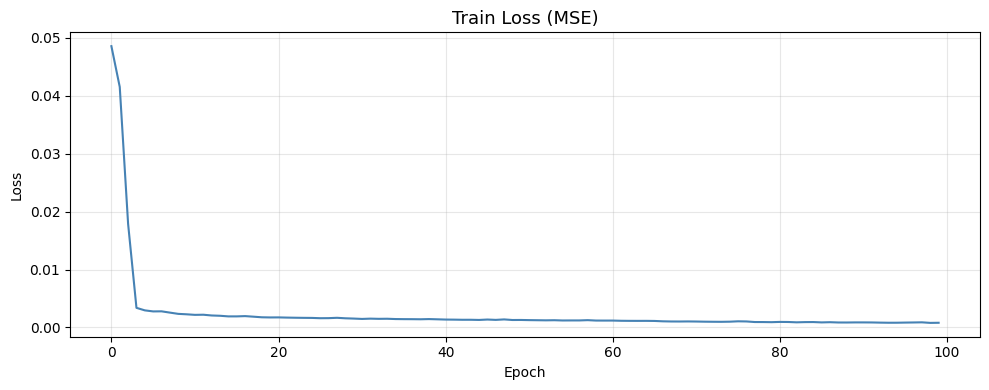

In [ ]:
# ✅ 11. Loss 그래프
plt.figure(figsize=(10, 4))
plt.plot(loss_graph, color="steelblue", linewidth=1.5)
plt.title("Train Loss (MSE)", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. 예측 및 시각화

학습이 끝난 모델로 전체 데이터(학습 + 테스트)에 대한 예측을 수행하고,  
실제 종가와 비교해봅니다.

세로 점선의 **왼쪽이 학습 구간**, 오른쪽이 **테스트 구간**입니다.


/tmp/ipykernel_2207/1135108618.py:24: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2207/1135108618.py:24: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2207/1135108618.py:24: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2207/1135108618.py:24: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2207/1135108618.py:24: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2207/1135108618.py:24: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2207/1135108618.py:24: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  plt.tight_l

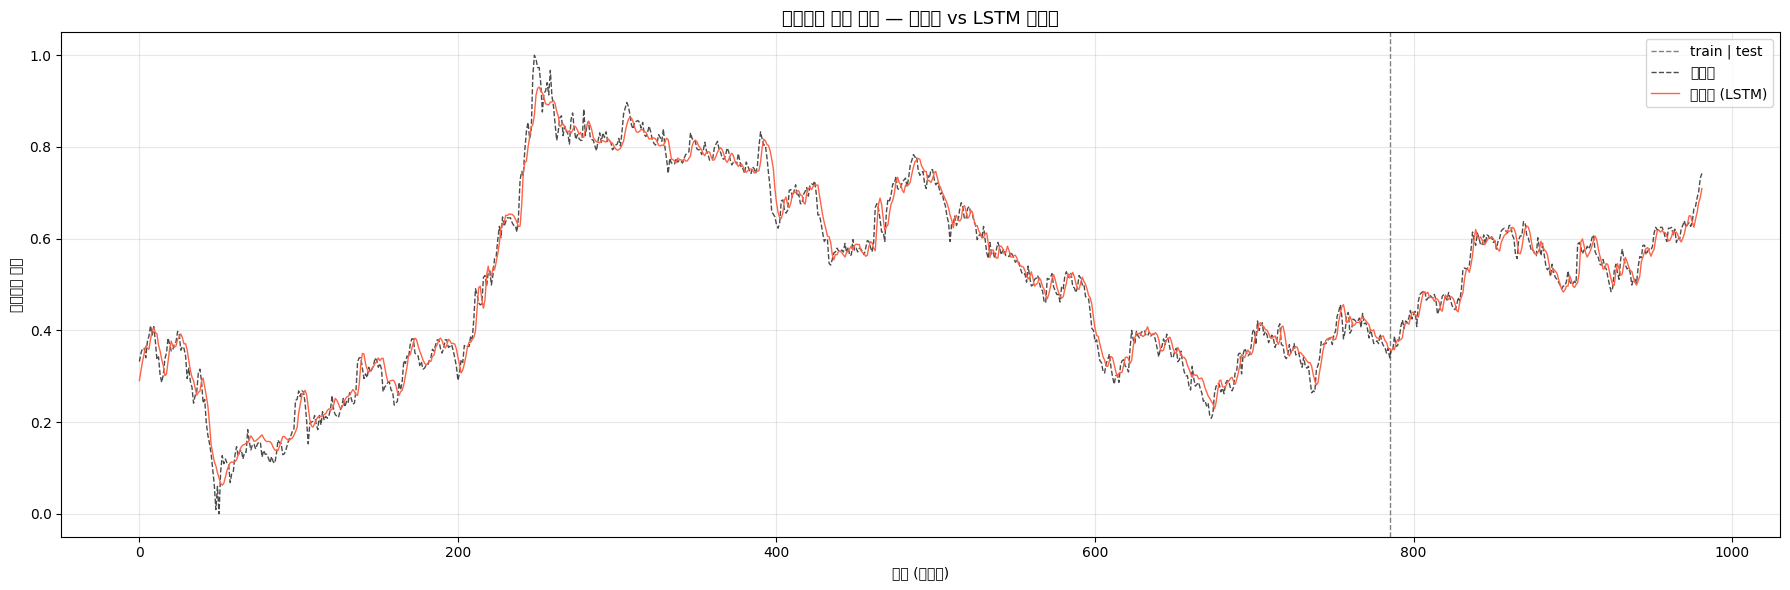

In [ ]:
# ✅ 12. 전체 데이터 예측 및 시각화
concat_dataset = TensorDataset(x_seq, y_seq)
data_loader    = DataLoader(concat_dataset, batch_size=100)

with torch.no_grad():
    pred = []
    model.eval()
    for seq, target in data_loader:
        out = model(seq)
        pred += out.cpu().tolist()

plt.figure(figsize=(18, 6))
# 학습/테스트 경계선
plt.axvline(x=split, color="gray", linestyle="--", linewidth=1, label="train | test")
# 실제값
plt.plot(df["Close"].values[sequence_length:], "--", color="black", linewidth=1, alpha=0.7, label="Actual")
# 예측값
plt.plot(pred, color="tomato", linewidth=1, label="Predicted (LSTM)")
plt.title("Samsung Electronics Close Price — Actual vs LSTM Predicted", fontsize=13)
plt.xlabel("Time (Trading Days)")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


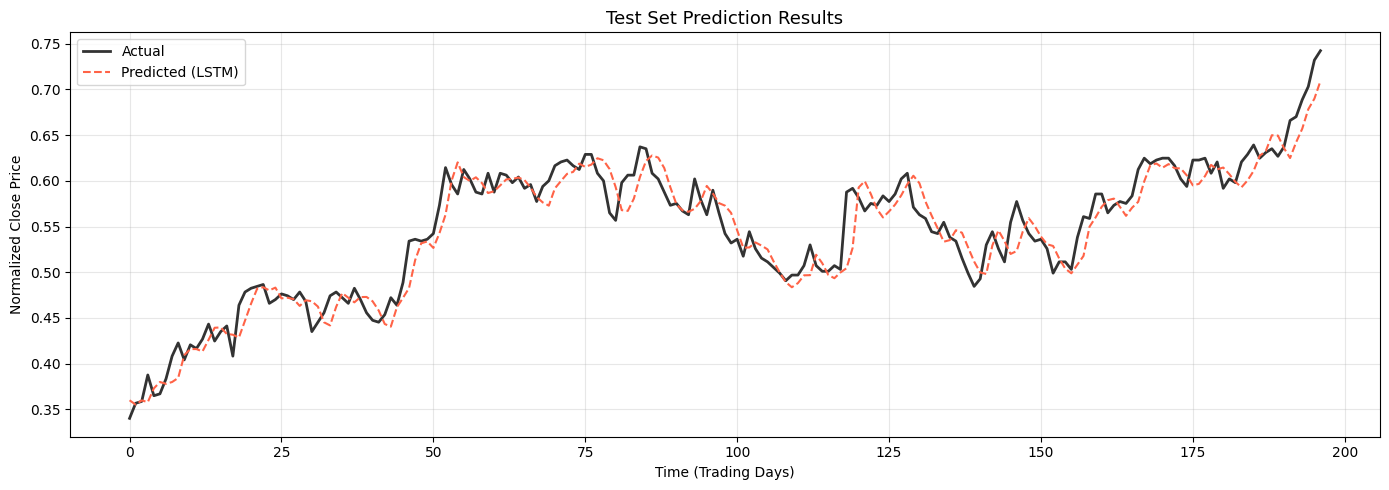


📊 테스트 MSE : 0.000461


In [ ]:
# ✅ 13. 테스트 구간만 따로 시각화
test_true = y_test.cpu().numpy().flatten()
test_pred = []

with torch.no_grad():
    model.eval()
    for seq, target in test_loader:
        out = model(seq)
        test_pred += out.cpu().tolist()

test_pred = np.array(test_pred).flatten()

plt.figure(figsize=(14, 5))
plt.plot(test_true, label="Actual",         color="black",  linewidth=2, alpha=0.8)
plt.plot(test_pred, label="Predicted (LSTM)", color="tomato", linewidth=1.5, linestyle="--")
plt.title("Test Set Prediction Results", fontsize=13)
plt.xlabel("Time (Trading Days)")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

test_mse = np.mean((test_pred - test_true) ** 2)
print(f"\n📊 테스트 MSE : {test_mse:.6f}")


## 8. 연습 문제

### Exercise 1 — 하이퍼파라미터 조정

아래 값들을 바꿔가며 MSE 변화를 확인해보세요.

1. `sequence_length` : 5 → 10, 20, 30  
2. `hidden_size` : 8 → 16, 32, 64  
3. `num_layers` : 2 → 1, 3  
4. `lr` : 1e-3 → 1e-4, 1e-2

### Exercise 2 — 다른 종목으로 예측

`ticker`를 바꿔서 다른 종목의 주가를 예측해보세요.

```python
ticker = "005380"   # 현대자동차
ticker = "000660"   # SK하이닉스
ticker = "035720"   # 카카오
```

종목마다 최적의 하이퍼파라미터가 달라질 수 있습니다.

### 💬 생각해볼 점

> MSE가 낮다고 해서 좋은 모델일까요?  
> 투자 관점에서는 "내일 오를까, 내릴까"를 맞히는 **방향성 정확도(Directional Accuracy)**가  
> MSE보다 더 중요할 수도 있습니다.


[epoch   0]  loss: 0.0506
[epoch  20]  loss: 0.0018
[epoch  40]  loss: 0.0014
[epoch  60]  loss: 0.0011
[epoch  80]  loss: 0.0010

📊 [005930] Test MSE : 0.000519  (seq=5, hidden=8, layers=2)


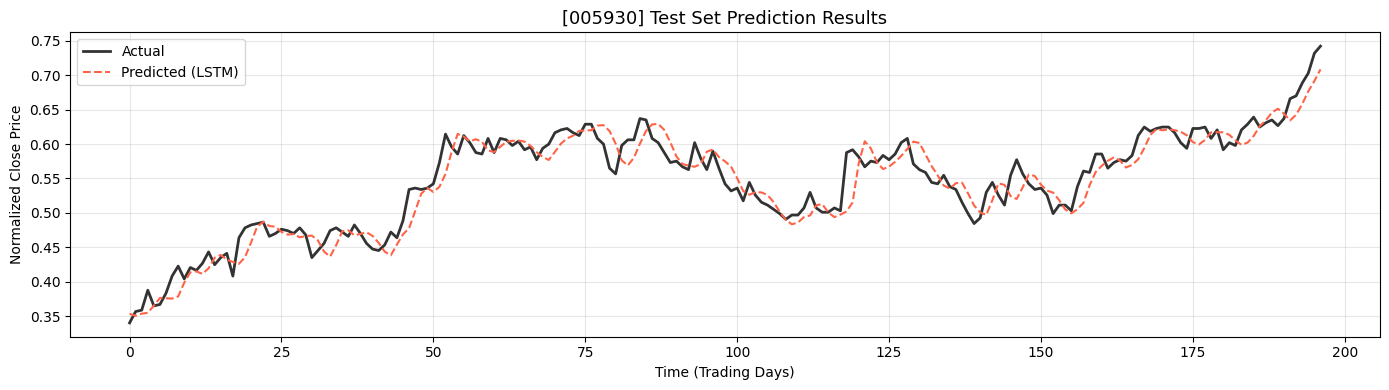

In [ ]:
# ✅ [Exercise] 하이퍼파라미터를 바꿔가며 실험해보세요!

# ── 변경 가능한 파라미터 ───────────────────────────────────────
sequence_length_ex = 5    # ← 바꿔보세요: 10, 20, 30
hidden_size_ex     = 8    # ← 바꿔보세요: 16, 32, 64
num_layers_ex      = 2    # ← 바꿔보세요: 1, 3
lr_ex              = 1e-3 # ← 바꿔보세요: 1e-4, 1e-2
ticker_ex          = "005930"  # ← 바꿔보세요: "005380", "000660"
# ──────────────────────────────────────────────────────────────

# 데이터 불러오기
df_ex = fdr.DataReader(ticker_ex, "2020", "2024")
df_ex = df_ex[["Open", "High", "Low", "Close", "Volume"]].dropna()

scaler_ex = MinMaxScaler()
df_ex[["Open", "High", "Low", "Close", "Volume"]] = scaler_ex.fit_transform(
    df_ex[["Open", "High", "Low", "Close", "Volume"]]
)

x_ex = df_ex[["Open", "High", "Low", "Volume"]].values
y_ex = df_ex["Close"].values

x_seq_ex, y_seq_ex = seq_data(x_ex, y_ex, sequence_length_ex)
split_ex = int(len(x_seq_ex) * 0.8)

x_train_ex, y_train_ex = x_seq_ex[:split_ex], y_seq_ex[:split_ex]
x_test_ex,  y_test_ex  = x_seq_ex[split_ex:], y_seq_ex[split_ex:]

train_loader_ex = DataLoader(TensorDataset(x_train_ex, y_train_ex), batch_size=20, shuffle=True)
test_loader_ex  = DataLoader(TensorDataset(x_test_ex,  y_test_ex),  batch_size=20, shuffle=False)

# 모델 생성 및 학습
model_ex    = VanillaLSTM(x_seq_ex.size(2), hidden_size_ex, sequence_length_ex, num_layers_ex, DEVICE).to(DEVICE)
optimizer_ex = optim.Adam(model_ex.parameters(), lr=lr_ex)
criterion_ex = nn.MSELoss()

model_ex.train()
for epoch in range(100):
    running_loss = 0
    for seq, target in train_loader_ex:
        out  = model_ex(seq)
        loss = criterion_ex(out, target)
        optimizer_ex.zero_grad()
        loss.backward()
        optimizer_ex.step()
        running_loss += loss.item()
    if epoch % 20 == 0:
        print(f"[epoch {epoch:3d}]  loss: {running_loss/len(train_loader_ex):.4f}")

# 평가
model_ex.eval()
with torch.no_grad():
    pred_ex, true_ex = [], []
    for seq, target in test_loader_ex:
        pred_ex += model_ex(seq).cpu().tolist()
        true_ex += target.cpu().tolist()

pred_ex = np.array(pred_ex).flatten()
true_ex = np.array(true_ex).flatten()
mse_ex  = np.mean((pred_ex - true_ex) ** 2)
print(f"\n📊 [{ticker_ex}] Test MSE : {mse_ex:.6f}  "
      f"(seq={sequence_length_ex}, hidden={hidden_size_ex}, layers={num_layers_ex})")

# Visualization
plt.figure(figsize=(14, 4))
plt.plot(true_ex, label="Actual",          color="black",  linewidth=2, alpha=0.8)
plt.plot(pred_ex, label="Predicted (LSTM)", color="tomato", linewidth=1.5, linestyle="--")
plt.title(f"[{ticker_ex}] Test Set Prediction Results", fontsize=13)
plt.xlabel("Time (Trading Days)")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
